# Scoring de Risque CNSS : Évaluation & Analyse Métier

Ce notebook charge le modèle XGBoost , applique le scoring sur le jeu de test et produit des analyses métier : segmentation, lift, optimisation du seuil de décision et simulation financière.

**Étapes :**
1. Chargement et préparation des données
2. Entraînement du modèle XGBoost final
3. Calcul des scores et segmentation des affiliés
4. Analyses de performance (taux de défaut, lift)
5. Simulation financière et optimisation du seuil
6. Sauvegarde du modèle et des artefacts


In [1]:
# Librairies pour le scoring, la visualisation et la connexion Oracle
import pandas as pd
import numpy as np
import oracledb
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score

## 1. Chargement des Données

In [2]:
# Connexion Oracle et chargement complet du dataset
conn = oracledb.connect(
    user="pfe",
    password="pfe",
    dsn="127.0.0.1:1521/XEPDB1"
)

query = "SELECT * FROM dataset_final1"
df = pd.read_sql(query, conn)

C:\Users\fatimazahra\AppData\Local\Temp\ipykernel_5160\3388898939.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


## 2. Préparation des Variables

In [3]:
# Extraction de la cible (1=défaut, 0=sain) et suppression des colonnes non utiles.
# Les libellés textuels et autres targets sont écartés pour éviter la fuite de données.
y = df["TARGET_FLAG_CLEAN"]

df = df.drop(columns=[
    "LIBELLE_SECTEUR",
    "LIBELLE_REGION",
    "LIBELLE_VILLE",
    "TARGET_RECOUVREMENT",
    "TARGET_POURCENTAGE_IMPAYE",
    "TARGET_POURCENTAGE_PAYE",
    "FLAG_GLOBAL",
    "TARGET_RECOUVREMENT_PAYE",
])

X = df.drop("TARGET_FLAG_CLEAN", axis=1)

## 3. Split Train / Test par Affilié

In [4]:
# Split stratifié par NUM_AFF : les 130 000 premiers affiliés vont au train,
# les restants au test. Cette approche évite tout data leakage inter-affiliés.
affilies = df["NUM_AFF"].unique()

np.random.seed(42)
np.random.shuffle(affilies)

train_aff = affilies[:130000]
test_aff  = affilies[130000:]

test_df = df[df["NUM_AFF"].isin(test_aff)].copy()

y_test = test_df["TARGET_FLAG_CLEAN"]
X_test = test_df.drop(columns=["TARGET_FLAG_CLEAN"])


## 4. Normalisation

In [5]:

X_test = X_test.select_dtypes(include=["int64", "float64"])

## 4.Chargement du scaler et application de la normalisation

In [6]:
scaler = joblib.load("models_v2/scaler_v2.pkl")
X_test_scaled = scaler.transform(X_test)

## 5.Chargement du modèle entraîné

In [7]:
best_xgb = joblib.load("models_v2/model_v2.pkl")

## 6.Prédiction

In [8]:
# Calcul des probabilités de défaut sur le jeu de test
y_proba = best_xgb.predict_proba(X_test_scaled)[:, 1]

## 7. Construction du DataFrame de Scoring

In [9]:
# Création d'un DataFrame enrichi avec la vérité terrain (y_true)
# et la probabilité de défaut prédite (proba_defaut).
df_score = test_df.copy()
df_score["y_true"] = y_test.values
df_score["proba_defaut"] = y_proba

In [10]:
# Conversion de la probabilité en score sur une échelle 0-1000
df_score["score"] = df_score["proba_defaut"] * 1000

## 8. Segmentation des Affiliés par Classe de Risque

In [11]:
# Règles de segmentation basées sur le score :
#   0-200    → Faible    (faible probabilité de défaut)
#   200-500  → Modéré
#   500-800  → Élevé
#   800-1000 → Très Élevé (priorité recouvrement)
def segment(score):
    if score <= 200:
        return 'Faible'
    elif score <= 500:
        return 'Modéré'
    elif score <= 800:
        return 'Élevé'
    else:
        return 'Très Élevé'

df_score['classe_risque'] = df_score['score'].apply(segment)
print(df_score['classe_risque'].value_counts())

classe_risque
Faible        18302
Très Élevé     2854
Élevé           917
Modéré          761
Name: count, dtype: int64


## 9. Analyse de Performance du Modèle

classe_risque
Faible        0.000164
Modéré        0.032852
Très Élevé    0.637351
Élevé         0.179935
Name: y_true, dtype: float64


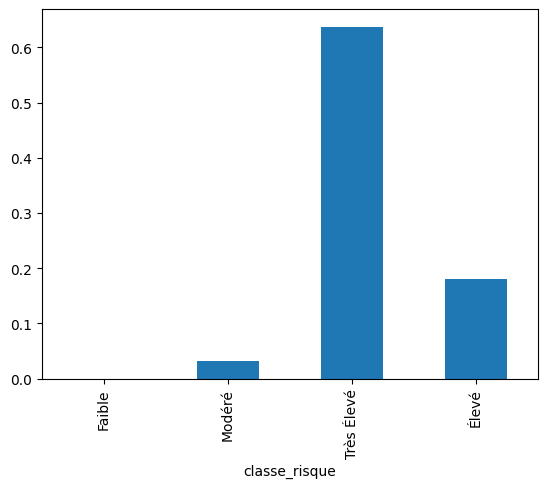

In [12]:
# Taux de défaut réel par segment : valide la cohérence du scoring.
# Un bon modèle doit montrer un taux croissant du segment Faible vers Très Élevé.
taux_defaut = df_score.groupby('classe_risque')['y_true'].mean()
print(taux_defaut)
taux_defaut.plot(kind='bar')
plt.show()

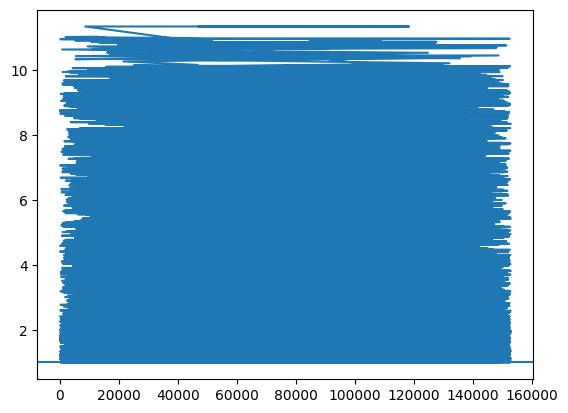

In [13]:
# Courbe de lift : mesure la performance du modèle par rapport à une sélection aléatoire.
# Un lift > 1 indique que le modèle capte mieux les défauts que le hasard.
# Les affiliés sont triés par proba_defaut décroissante pour maximiser la capture.
df_sorted = df_score.sort_values('proba_defaut', ascending=False)
df_sorted['cum_defaut'] = df_sorted['y_true'].cumsum()
df_sorted['cum_total'] = range(1, len(df_sorted)+1)
df_sorted['lift'] = (df_sorted['cum_defaut']/df_sorted['cum_total']) / df_sorted['y_true'].mean()
plt.plot(df_sorted['lift'])
plt.axhline(1)
plt.show()

In [14]:
# Analyse ciblée du segment 'Très Élevé' :
# Calcul du nombre de défauts effectivement captés dans ce groupe à haut risque.
# Le taux de capture doit être nettement supérieur à la moyenne globale.
zone = df_score[df_score["classe_risque"] == "Très Élevé"]

total = len(zone)
defauts = zone["y_true"].sum()

print("Clients Très Élevé:", total)
print("Défauts captés:", defauts)
print("Taux capture:", defauts / total)

Clients Très Élevé: 2854
Défauts captés: 1819
Taux capture: 0.6373510861948143


In [15]:
# Analyse top 20% : les 20% d'affiliés les plus risqués concentrent-ils
# une proportion élevée des défauts réels ? (indicateur clé de puissance discriminante)
top_20 = df_score.sort_values(by='proba_defaut', ascending=False).head(int(0.2 * len(df_score)))
print('Taux top20:', top_20['y_true'].mean())
print('Taux global:', df_score['y_true'].mean())

Taux top20: 0.4404292597459483
Taux global: 0.08811421564333888


## 10. Règles de Décision Métier

In [16]:
# Attribution d'une décision opérationnelle selon la probabilité de défaut :

def decision(p):
    if p < 0.05:
        return "ACCEPTER"
    elif p < 0.15:
        return "SURVEILLANCE"
    elif p < 0.40:
        return "SURVEILLANCE RENFORCÉE"
    else:
        return "RECOUVREMENT"

df_score["decision"] = df_score["proba_defaut"].apply(decision)

print(df_score["decision"].value_counts())

decision
ACCEPTER                  17684
RECOUVREMENT               3981
SURVEILLANCE RENFORCÉE      698
SURVEILLANCE                471
Name: count, dtype: int64


In [17]:
print(df_score["proba_defaut"].value_counts(bins=10))

(-0.001987, 0.0988]    17952
(0.889, 0.988]          2246
(0.791, 0.889]           643
(0.692, 0.791]           392
(0.0988, 0.198]          346
(0.198, 0.296]           308
(0.593, 0.692]           262
(0.494, 0.593]           238
(0.296, 0.395]           235
(0.395, 0.494]           212
Name: count, dtype: int64


## 11. Simulation Financière

In [18]:
# Simulation financière du modèle avec un seuil fixe à 0.4 :
#   Bon client (y=0) : gain de 1000 unités
#   Mauvais client (y=1) : perte de 5000 unités
#   Action de recouvrement : coût fixe de 500 unités
# Comparaison entre le gain avec et sans l'utilisation du modèle.
gain_bon = 1000
perte_mauvais = -5000
cout_recouvrement = 500

# ============================================
# JUSTIFICATION DU RATIO PERTE / GAIN
# ============================================

# Nous avons supposé un ratio perte/gain égal à 5.
# Cela signifie que la perte engendrée par un client en défaut
# est estimée à 5 fois le gain généré par un client solvable.

# Ce ratio (5000 / 1000 = 5) est cohérent avec les pratiques
# du scoring de risque de crédit, où le coût d’un impayé
# est généralement évalué entre 3 et 7 fois le gain attendu.

df_score["gain_reel"] = np.where(
    df_score["y_true"] == 0,
    gain_bon,
    perte_mauvais
)

df_score["action"] = np.where(
    df_score["proba_defaut"] > 0.4,
    1,
    0
)

df_score["gain_modele"] = np.where(
    df_score["action"] == 1,
    -cout_recouvrement,
    df_score["gain_reel"]
)
# calcul des sommes
gain_modele = df_score["gain_modele"].sum()
gain_sans_modele = df_score["gain_reel"].sum()

print("Gain modèle:", gain_modele)
print("Gain sans modèle:", gain_sans_modele)
print("Amélioration:", gain_modele - gain_sans_modele)


Gain modèle: 16766500
Gain sans modèle: 10762000
Amélioration: 6004500


## 12. Optimisation du Seuil de Décision

In [19]:
# Recherche du seuil optimal par balayage de 0.05 à 0.95.
# Pour chaque seuil, on calcule le gain total du modèle en tenant compte
# du coût de recouvrement et de la perte sur défauts non détectés.
# Le seuil maximisant le gain total est retenu comme seuil de production.
import numpy as np

gain_bon = 1000
perte_mauvais = -5000
cout_recouvrement = 500



# Gain réel (base business)
df_score["gain_reel"] = np.where(
    df_score["y_true"] == 0,
    gain_bon,
    perte_mauvais
)

# Liste des seuils à tester
seuils = np.arange(0.05, 0.95, 0.01)

resultats = []

for seuil in seuils:
    
    # décision
    action = (df_score["proba_defaut"] > seuil).astype(int)
    
    # gain modèle
    gain_modele = np.where(
        action == 1,
        -cout_recouvrement + df_score["gain_reel"],
        df_score["gain_reel"]
    ).sum()
    
    resultats.append((seuil, gain_modele))

# conversion en tableau
import pandas as pd

res_df = pd.DataFrame(resultats, columns=["seuil", "gain"])

# meilleur seuil
best = res_df.loc[res_df["gain"].idxmax()]

print("Meilleur seuil :", best["seuil"])
print("Gain optimal :", best["gain"])

Meilleur seuil : 0.9400000000000002
Gain optimal : 9956000.0


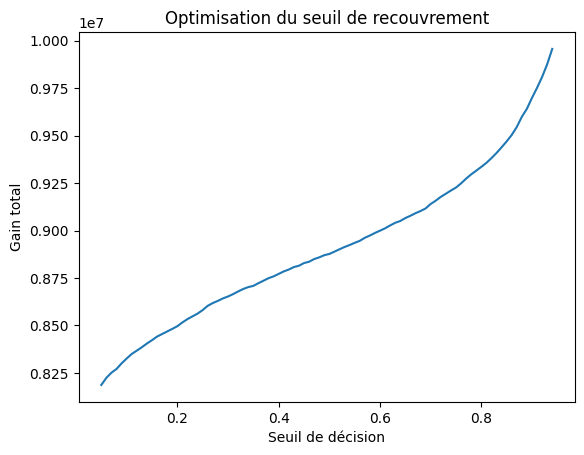

In [20]:
# Visualisation de la courbe gain = f(seuil).
# Permet d'identifier visuellement la zone de seuil optimal.
import matplotlib.pyplot as plt

plt.plot(res_df["seuil"], res_df["gain"])
plt.xlabel("Seuil de décision")
plt.ylabel("Gain total")
plt.title("Optimisation du seuil de recouvrement")
plt.show()